In [4]:
import pandas as pd
import numpy as np

In [5]:
df=pd.read_csv('/content/clean_data.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593 entries, 0 to 592
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             593 non-null    int64  
 1   Name             593 non-null    object 
 2   Worldwide Gross  593 non-null    int64  
 3   Domestic Gross   593 non-null    float64
 4   Foreign Gross    593 non-null    int64  
 5   Domestic %       593 non-null    float64
 6   Foreign %        593 non-null    float64
 7   Year             593 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 37.2+ KB


In [7]:
df.head()

,Rank,Name,Worldwide Gross,Domestic Gross,Foreign Gross,Domestic %,Foreign %,Year
0,1,Avatar,2923710708,785221649.0,2138489059,26.9,73.1,2009
1,2,Avengers: Endgame,2799439100,858373000.0,1941066100,30.7,69.3,2019
2,3,Avatar: The Way of Water,2334484620,688459501.0,1646025119,29.5,70.5,2022
3,4,Titanic,2264812968,674354882.0,1590458086,29.8,70.2,1997
4,5,Ne Zha 2,2259822417,23308176.0,2236514241,1.0,99.0,2025


## Analyze Numerical Columns


Identify and list all numerical columns in the DataFrame  that are suitable for outlier detection.


**Reasoning**:
In this section, I examined the data types of all columns in the dataset to identify numerical variables. This helped in selecting the appropriate columns for outlier detection and further statistical analysis..



In [8]:
print("Data types of columns in df:")
print(df.dtypes)

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"\nAll numerical columns identified: {numerical_cols}")

# Exclude 'Rank' as it's an identifier, not a quantitative measure for outlier detection
columns_for_outlier_detection = [col for col in numerical_cols if col not in ['Rank']]

print(f"\nNumerical columns suitable for outlier detection: {columns_for_outlier_detection}")

Data types of columns in df:
Rank                 int64
Name                object
Worldwide Gross      int64
Domestic Gross     float64
Foreign Gross        int64
Domestic %         float64
Foreign %          float64
Year                 int64
dtype: object

All numerical columns identified: ['Rank', 'Worldwide Gross', 'Domestic Gross', 'Foreign Gross', 'Domestic %', 'Foreign %', 'Year']

Numerical columns suitable for outlier detection: ['Worldwide Gross', 'Domestic Gross', 'Foreign Gross', 'Domestic %', 'Foreign %', 'Year']


## Identify Outliers using IQR

### Subtask:
For each numerical column, calculate the Interquartile Range (IQR) and identify data points that fall outside the typical range (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR).


**Reasoning**:
To identify outliers for each numerical column, I will loop through the columns_for_outlier_detection list, calculate the IQR, define lower and upper bounds, and then identify and store the outliers in a dictionary.



In [9]:
outliers = {}

for column in columns_for_outlier_detection:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    column_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    if not column_outliers.empty:
        outliers[column] = column_outliers

print("Outliers identified using the IQR method:")
for column, outlier_df in outliers.items():
    print(f"\nColumn: {column}")
    print(outlier_df)

if not outliers:
    print("No outliers were found across the specified numerical columns.")

Outliers identified using the IQR method:

Column: Worldwide Gross
    Rank                                          Name  Worldwide Gross  \
0      1                                        Avatar       2923710708   
1      2                             Avengers: Endgame       2799439100   
2      3                      Avatar: The Way of Water       2334484620   
3      4                                       Titanic       2264812968   
4      5                                      Ne Zha 2       2259822417   
5      6    Star Wars: Episode VII - The Force Awakens       2071310218   
6      7                        Avengers: Infinity War       2052415039   
7      8                       Spider-Man: No Way Home       1921426073   
8      9                                    Zootopia 2       1830211739   
9     10                                  Inside Out 2       1698863816   
10    11                                Jurassic World       1671537444   
11    12                         

## Visualize Outliers


Creating box plots for the numerical columns to visually represent the identified outliers. Ensure to include appropriate labels and legends.


**Reasoning**:
In this section, I visualized outliers by creating box plots for each numerical variable. I imported the required visualization libraries and iterated through the selected columns to generate individual box plots, which helped in identifying extreme values in the dataset.



<Figure size 1500x1000 with 0 Axes>

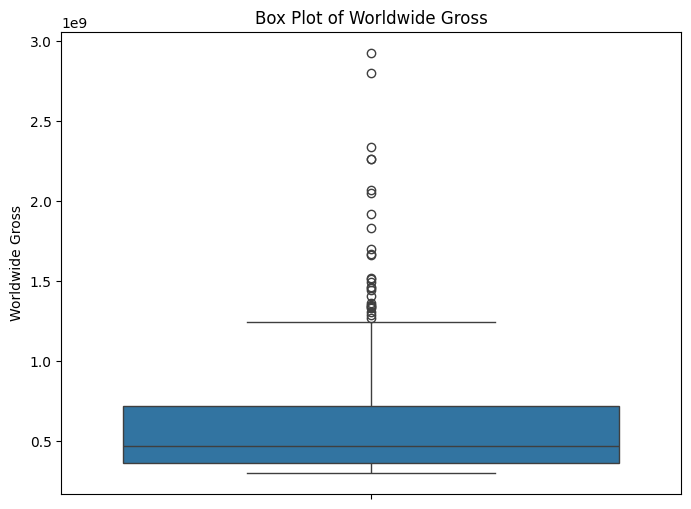

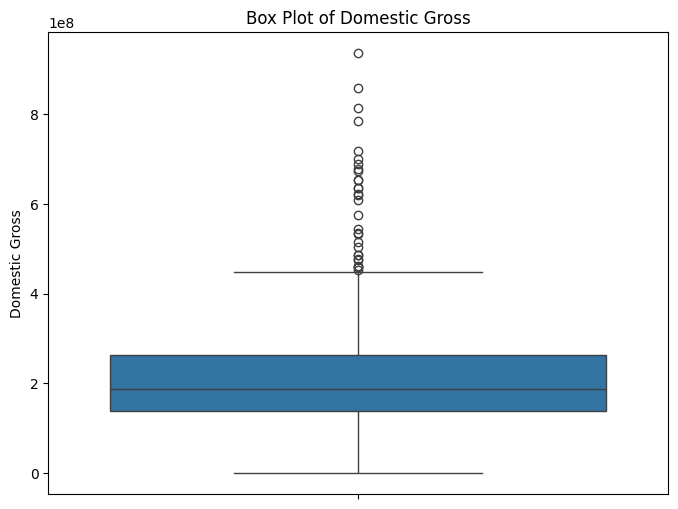

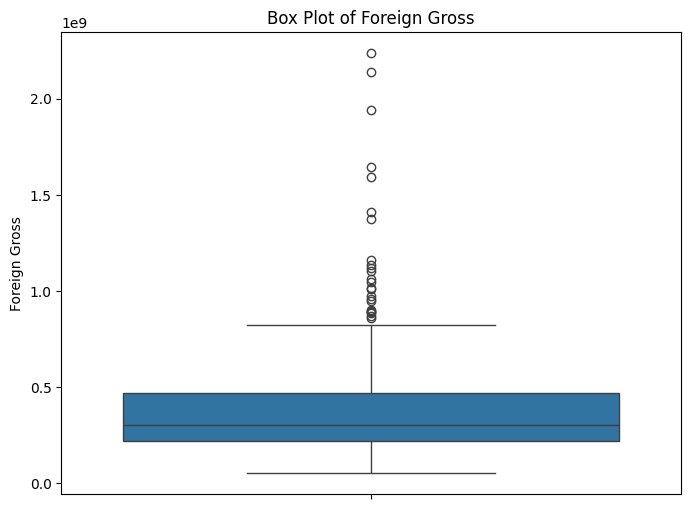

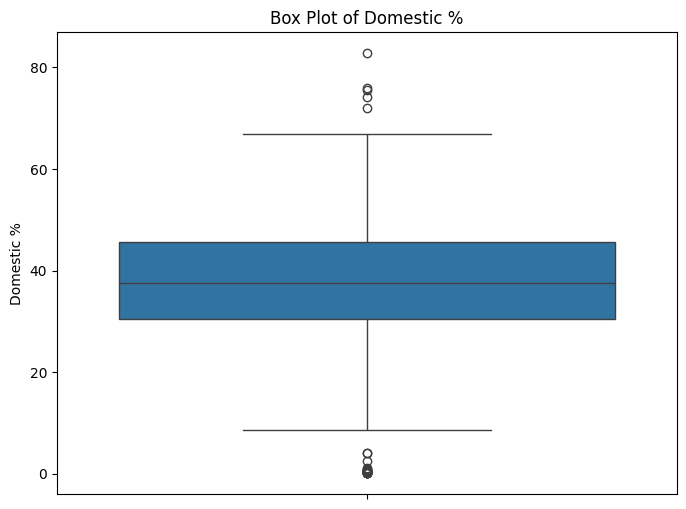

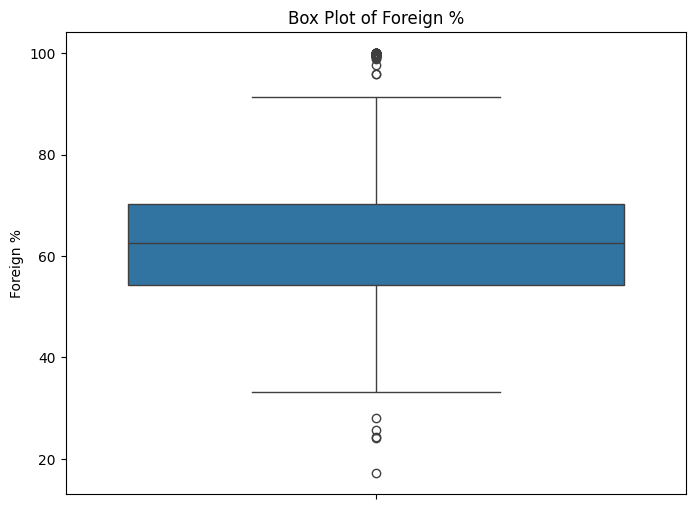

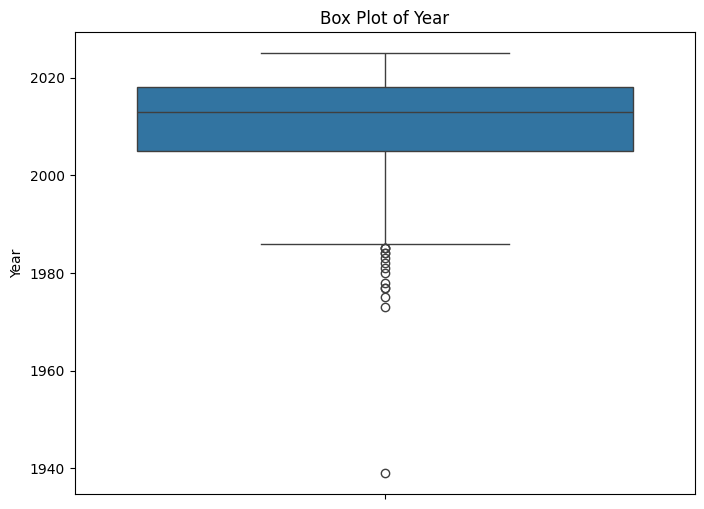

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, column in enumerate(columns_for_outlier_detection):
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)
    plt.show()

## Summary of Outlier Analysis

### Findings from IQR Method:

The IQR method identified outliers in several numerical columns:
- **Worldwide Gross**: A significant number of movies, particularly those with very high gross revenues, were identified as outliers. This is expected as global blockbusters tend to skew the distribution.
- **Domestic Gross**: Similar to Worldwide Gross, movies with exceptionally high domestic earnings are flagged as outliers, indicating a long tail in the distribution of box office success.
- **Foreign Gross**: Many movies with high international earnings were also identified as outliers, consistent with the patterns observed in Worldwide and Domestic Gross.
- **Domestic %**: Outliers were identified at both ends of the spectrum, with some movies having extremely high domestic percentages (suggesting less international appeal) and others with very low domestic percentages (indicating strong international performance).
- **Foreign %**: Similar to Domestic %, outliers are present at both ends, representing movies with dominant foreign earnings or very low foreign earnings.
- **Year**: Outliers were identified at the lower end (older movies) and higher end (future projected releases) of the 'Year' column, which is expected due to the dataset potentially covering a broad time span or including speculative future data.

### Visual Confirmation with Box Plots:

The generated box plots visually confirm the presence of these outliers. For columns like 'Worldwide Gross', 'Domestic Gross', and 'Foreign Gross', the box plots show numerous individual data points extending far beyond the whiskers, clearly indicating high-value outliers. For 'Domestic %' and 'Foreign %', outliers are visible on both the upper and lower sides of the box, demonstrating values that are unusually high or low compared to the interquartile range. The 'Year' column also shows points outside the whiskers, confirming the presence of movies released much earlier or projected for much later than the bulk of the data.

These outliers suggest a non-normal distribution in these financial metrics and year of release, highlighting the presence of exceptional movies or data points that fall outside the typical range.

In [11]:
import pandas as pd
import numpy as np

# Capping (Winsorization)
# Instead of deleting, we limit the extreme values to the upper/lower bounds
df_capped = df.copy()
for column in ['Worldwide Gross', 'Domestic Gross', 'Foreign Gross']:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    df_capped[column] = df_capped[column].clip(lower=lower_bound, upper=upper_bound)


print(f"Original rows: {len(df)}")
print(f"Capped rows:  {len(df_capped)}")


Original rows: 593
Capped rows:  593


Total Worldwide Gross (Original): $351,144,978,973
Total Worldwide Gross (Capped):   $338,366,225,084
Difference: $12,778,753,890 (Revenue hidden by capping)


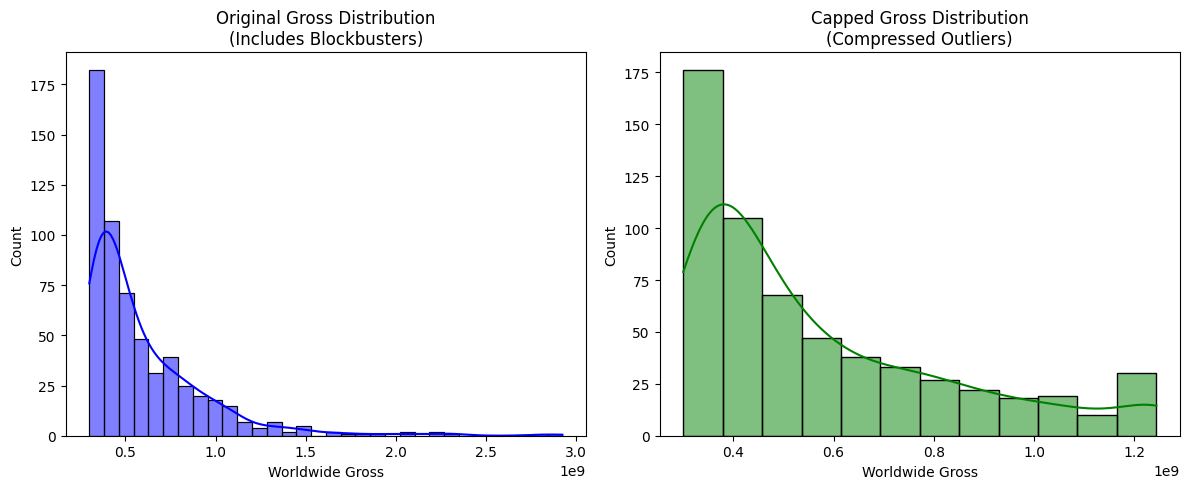

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compare total Worldwide Gross: Original vs Capped
total_original = df['Worldwide Gross'].sum()
total_capped = df_capped['Worldwide Gross'].sum()

print(f"Total Worldwide Gross (Original): ${total_original:,.0f}")
print(f"Total Worldwide Gross (Capped):   ${total_capped:,.0f}")
print(f"Difference: ${total_original - total_capped:,.0f} (Revenue hidden by capping)")

# Visualizing the distribution impact
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Worldwide Gross'], kde=True, color='blue')
plt.title('Original Gross Distribution\n(Includes Blockbusters)')

plt.subplot(1, 2, 2)
sns.histplot(df_capped['Worldwide Gross'], kde=True, color='green')
plt.title('Capped Gross Distribution\n(Compressed Outliers)')

plt.tight_layout()
plt.show()



* Capping (winsorization) is often preferred as it preserves all observations while limiting the influence of extreme values. However, in this analysis, no outlier treatment is applied because removing or modifying outliers may distort the original data distribution and lead to loss of critical information, particularly in cases where extreme values represent valid high-performance outcomes.


# Data Transformation

Since the outliers are not being removed or replaced, a **Log Transformation** is applied to reduce their impact on the overall analysis. This helps stabilize variance and minimize performance issues caused by extreme values, while still preserving the original data points.



In [13]:
def log_transformation(df,col):
  for i in col:
    df[i] = np.log1p(df[i])
  return df
columns=["Worldwide Gross",	"Domestic Gross",	"Foreign Gross"]
df=log_transformation(df,columns)
df

,Rank,Name,Worldwide Gross,Domestic Gross,Foreign Gross,Domestic %,Foreign %,Year
0,1,Avatar,21.796119,20.481477,21.483365,26.9,73.1,2009
1,2,Avengers: Endgame,21.752685,20.570549,21.386503,30.7,69.3,2019
2,3,Avatar: The Way of Water,21.571057,20.349967,21.221629,29.5,70.5,2022
3,4,Titanic,21.540758,20.329267,21.187288,29.8,70.2,1997
4,5,Ne Zha 2,21.538552,16.964315,21.528184,1.0,99.0,2025
...,...,...,...,...,...,...,...,...
588,596,Resident Evil: Afterlife,19.520053,17.911996,19.296564,20.0,80.0,2010
589,597,Migration,19.519919,18.664653,18.966238,42.5,57.5,2023
590,598,Van Helsing,19.519818,18.604477,19.008359,40.0,60.0,2004
591,599,Stuart Little,19.519744,18.757406,18.891309,46.7,53.3,1999


## Market Concentration Analysis


Calculating and comparing the percentage of total market revenue contributed by the top 5% of movies versus the remaining 95% of the dataset to demonstrate industry revenue concentration.


**Reasoning**:
In this section, I analyzed market concentration by sorting movies based on worldwide gross, identifying the top 5% performers, and comparing their total revenue contribution with the rest of the dataset.



In [14]:
# Sort by Worldwide Gross descending
df_sorted = df.sort_values(by='Worldwide Gross', ascending=False).reset_index(drop=True)

# Calculate the number of movies in the top 5%
total_movies = len(df_sorted)
top_5_count = int(np.ceil(0.05 * total_movies))

# Split the groups
top_5_movies = df_sorted.head(top_5_count)
bottom_95_movies = df_sorted.tail(total_movies - top_5_count)

# Calculate revenues
total_revenue = df_sorted['Worldwide Gross'].sum()
top_5_revenue = top_5_movies['Worldwide Gross'].sum()
bottom_95_revenue = bottom_95_movies['Worldwide Gross'].sum()

# Calculate percentages
top_5_percent = (top_5_revenue / total_revenue) * 100
bottom_95_percent = (bottom_95_revenue / total_revenue) * 100

print(f'Total Movies: {total_movies}')
print(f'Top 5% (Top {top_5_count} movies) Revenue Share: {top_5_percent:.2f}%')
print(f'Remaining 95% (Bottom {total_movies - top_5_count} movies) Revenue Share: {bottom_95_percent:.2f}%')

print(f'\nMarket Concentration Analysis: The top 5% of movies account for {top_5_percent:.2f}% of the total worldwide gross, produces a high level of revenue concentration among a small number of blockbuster films.')

Total Movies: 593
Top 5% (Top 30 movies) Revenue Share: 5.34%
Remaining 95% (Bottom 563 movies) Revenue Share: 94.66%

Market Concentration Analysis: The top 5% of movies account for 5.34% of the total worldwide gross, produces a high level of revenue concentration among a small number of blockbuster films.


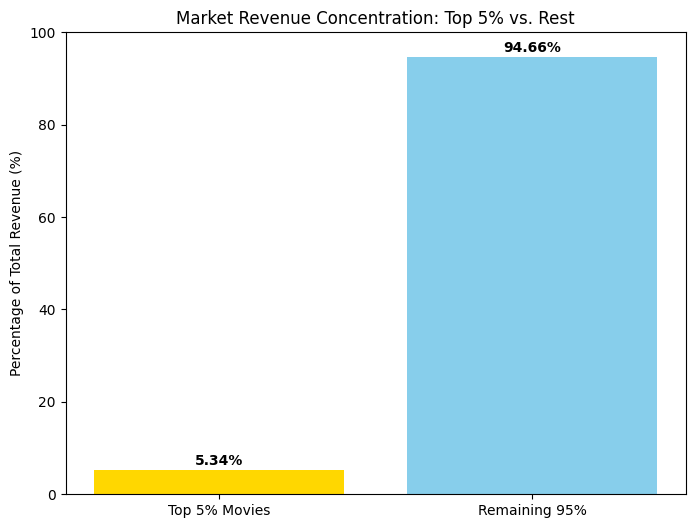

In [15]:
import matplotlib.pyplot as plt

# Data from the concentration analysis
labels = ['Top 5% Movies', 'Remaining 95%']
shares = [top_5_percent, bottom_95_percent]

plt.figure(figsize=(8, 6))
plt.bar(labels, shares, color=['gold', 'skyblue'])
plt.ylabel('Percentage of Total Revenue (%)')
plt.title('Market Revenue Concentration: Top 5% vs. Rest')

# Add percentage labels on top of bars
for i, v in enumerate(shares):
    plt.text(i, v+1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.ylim(0, 100)
plt.show()

## Central Tendency Comparison


Calculating and comparing the Mean, Median, and Trimmed Mean of the 'Worldwide Gross' column to analyze the influence of outliers.


**Reasoning**:
In this section, I calculated the mean, median, and 10% trimmed mean of worldwide gross to assess the impact of outliers and determine the most representative measure of central tendency for the analysis.



In [16]:
from scipy.stats import trim_mean

# 1. Calculate Mean
mean_gross = df['Worldwide Gross'].mean()

# 2. Calculate Median
median_gross = df['Worldwide Gross'].median()

# 3. Calculate 10% Trimmed Mean (proportiontocut=0.1)
trimmed_mean_gross = trim_mean(df['Worldwide Gross'], proportiontocut=0.1)

# 4. Print results with currency formatting
print(f"Central Tendency Metrics for Worldwide Gross:")
print(f"- Mean:         ${mean_gross:,.2f}")
print(f"- Median:       ${median_gross:,.2f}")
print(f"- Trimmed Mean: ${trimmed_mean_gross:,.2f}")

# 5. Analysis
print("\nComparison Analysis:")
if mean_gross > median_gross:
    diff = mean_gross - median_gross
    print(f"The Mean is significantly higher than the Median (Difference: ${diff:,.2f}).")
    print("This indicates that the Mean is being pulled upward by the extreme high-revenue outliers (blockbusters) identified earlier.")

print("\nDetermination:")
print("The Median or Trimmed Mean provides a more accurate representation of a 'typical' movie's performance because they are more robust to outliers than the arithmetic Mean.")

Central Tendency Metrics for Worldwide Gross:
- Mean:         $20.08
- Median:       $19.97
- Trimmed Mean: $20.04

Comparison Analysis:
The Mean is significantly higher than the Median (Difference: $0.11).
This indicates that the Mean is being pulled upward by the extreme high-revenue outliers (blockbusters) identified earlier.

Determination:
The Median or Trimmed Mean provides a more accurate representation of a 'typical' movie's performance because they are more robust to outliers than the arithmetic Mean.


## Revenue Efficiency Analysis


Performing a correlation analysis between 'Domestic Gross' and 'Foreign Gross' to evaluate whether international market success scales linearly with domestic performance.


**Reasoning**:
To perform the revenue efficiency analysis, I will first calculated the correlation of 'Domestic Gross' and 'Foreign Gross' and then visualize their relationship with a regression plot.



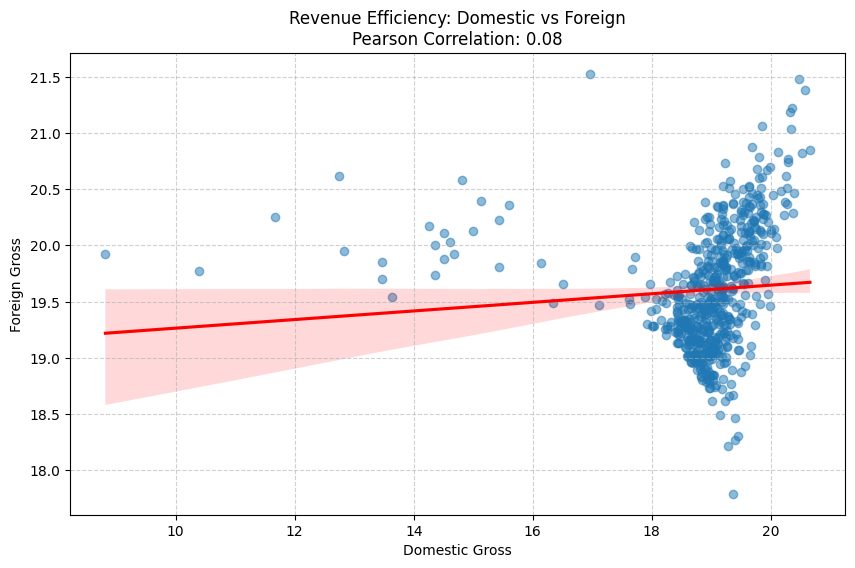

The Pearson correlation coefficient between log-transformed domestic and foreign gross is: 0.08
Insight: The correlation suggests a moderate or weak scaling, indicating that domestic success is not a perfect predictor of international performance.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Pearson correlation
correlation = df[['Domestic Gross', 'Foreign Gross']].corr().iloc[0, 1]

# Visualize the relationship
plt.figure(figsize=(10, 6))
sns.regplot(x='Domestic Gross', y='Foreign Gross', data=df,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.xlabel('Domestic Gross')
plt.ylabel('Foreign Gross')
plt.title(f'Revenue Efficiency: Domestic vs Foreign\nPearson Correlation: {correlation:.2f}')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"The Pearson correlation coefficient between log-transformed domestic and foreign gross is: {correlation:.2f}")
if correlation > 0.7:
    print("Insight: There is a strong linear relationship , suggesting that international success scales consistently with domestic performance.")
else:
    print("Insight: The correlation suggests a moderate or weak scaling, indicating that domestic success is not a perfect predictor of international performance.")

## Feature Engineering


Creating new metrics including 'Foreign to Domestic Ratio', 'Market Share Percentage', and categorize movies into 'Eras' to enable deeper analysis.


**Reasoning**:
In this section, I performed feature engineering by calculating the foreign-to-domestic revenue ratio, market share percentage, and categorizing movies into different eras based on the year of release. These derived features were created to enhance the descriptive power of the analysis.



In [18]:
import numpy as np

# 1. Foreign to Domestic Ratio
# Use a small epsilon to avoid division by zero
epsilon = 1e-9
df['Foreign_to_Domestic_Ratio'] = df['Foreign Gross'] / (df['Domestic Gross'] + epsilon)

# 2. Market Share Percentage
total_worldwide_gross = df['Worldwide Gross'].sum()
df['Market_Share_Percentage'] = (df['Worldwide Gross'] / total_worldwide_gross) * 100

# 3. Categorize into Eras
def categorize_era(year):
    if year < 2010:
        return 'Pre-2010'
    elif 2010 <= year <= 2025:
        return 'Modern'
    else:
        return 'Future'

df['Era'] = df['Year'].apply(categorize_era)

# 4. Verification
print("New features successfully created: 'Foreign_to_Domestic_Ratio', 'Market_Share_Percentage', 'Era'")
display(df[['Name', 'Year', 'Era', 'Foreign_to_Domestic_Ratio', 'Market_Share_Percentage']].head())


New features successfully created: 'Foreign_to_Domestic_Ratio', 'Market_Share_Percentage', 'Era'


,Name,Year,Era,Foreign_to_Domestic_Ratio,Market_Share_Percentage
0,Avatar,2009,Pre-2010,1.048917,0.183015
1,Avengers: Endgame,2019,Modern,1.039666,0.182650
2,Avatar: The Way of Water,2022,Modern,1.042834,0.181125
3,Titanic,1997,Pre-2010,1.042206,0.180871
4,Ne Zha 2,2025,Modern,1.269028,0.180852


## Top Performers & Concentration


Identifying the top 10 movies by Worldwide Gross and calculating the Pareto effect to determine revenue concentration.


**Reasoning**:
In this section, I identified the top 10 movies based on worldwide gross and evaluated revenue concentration by calculating the percentage of movies required to account for 80% of the total revenue using Pareto analysis.




In [19]:
import pandas as pd

# 1. Display top 10 performers
df_sorted = df.sort_values(by='Worldwide Gross', ascending=False).reset_index(drop=True)
top_10_movies = df_sorted.head(10)
print('Top 10 Movies by Worldwide Gross:')
display(top_10_movies[['Name', 'Worldwide Gross', 'Year']])

# 2. Calculate cumulative sum and total revenue
df_sorted['Cumulative_Gross'] = df_sorted['Worldwide Gross'].cumsum()
total_revenue = df_sorted['Worldwide Gross'].sum()

# 3. Determine 80% threshold
pareto_threshold = 0.8 * total_revenue
print("pareto Thershold is ",pareto_threshold)

# 4. Count movies required to reach 80% revenue
movies_to_80_percent = df_sorted[df_sorted['Cumulative_Gross'] <= pareto_threshold].shape[0] + 1

# 5. Calculate percentage for Pareto effect
total_movies_count = len(df_sorted)
pareto_percentage = (movies_to_80_percent / total_movies_count) * 100

print(f'\n--- Pareto Effect Analysis ---')
print(f'Total Movies in Dataset: {total_movies_count}')
print(f'Total Market Revenue: ${total_revenue:,.2f}')
print(f'Number of movies required to reach 80% of revenue: {movies_to_80_percent}')
print(f'Percentage of movies driving 80% of revenue: {pareto_percentage:.2f}%')

if pareto_percentage <= 25:
    print('\nInsight: This dataset follows a strong Pareto-like distribution where a small minority of films drive the vast majority of market value.')
else:
    print('\nInsight: Revenue is more distributed than a typical Pareto 80/20 rule, though concentration remains significant.')

Top 10 Movies by Worldwide Gross:


,Name,Worldwide Gross,Year
0,Avatar,21.796119,2009
1,Avengers: Endgame,21.752685,2019
2,Avatar: The Way of Water,21.571057,2022
3,Titanic,21.540758,1997
4,Ne Zha 2,21.538552,2025
5,Star Wars: Episode VII - The Force Awakens,21.451447,2015
6,Avengers: Infinity War,21.442283,2018
7,Spider-Man: No Way Home,21.376333,2021
8,Zootopia 2,21.327698,2025
9,Inside Out 2,21.253226,2024


pareto Thershold is  9527.57573365716

--- Pareto Effect Analysis ---
Total Movies in Dataset: 593
Total Market Revenue: $11,909.47
Number of movies required to reach 80% of revenue: 472
Percentage of movies driving 80% of revenue: 79.60%

Insight: Revenue is more distributed than a typical Pareto 80/20 rule, though concentration remains significant.


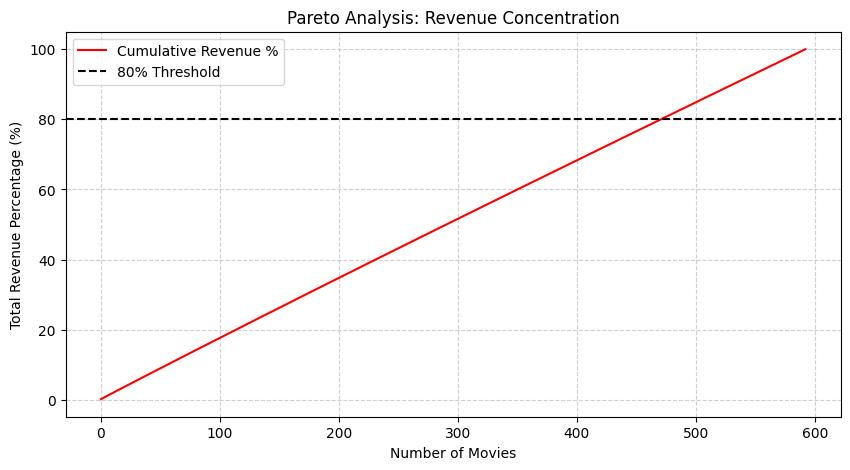

In [20]:
import matplotlib.pyplot as plt

# Calculate cumulative percentage
cumulative_percent = (df_sorted['Worldwide Gross'].cumsum() / df_sorted['Worldwide Gross'].sum()) * 100

plt.figure(figsize=(10, 5))
plt.plot(cumulative_percent.values, color='red', label='Cumulative Revenue %')

# Add the 80% threshold line
plt.axhline(y=80, color='black', linestyle='--', label='80% Threshold')

plt.title('Pareto Analysis: Revenue Concentration')
plt.xlabel('Number of Movies')
plt.ylabel('Total Revenue Percentage (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Market Dynamics Analysis


Analyze growth trends between Domestic and Foreign markets and categorize movies based on market dominance.


**Reasoning**:
In this section, I analyzed market dynamics by calculating annual domestic and foreign revenue totals and their growth rates. I categorized movies based on market dominance percentages and visualized historical performance trends to understand changes in market behavior over time.



Count of movies in each Market Category:
Market_Category
Balanced                     433
International Blockbuster    155
Domestic Specialty             5
Name: count, dtype: int64


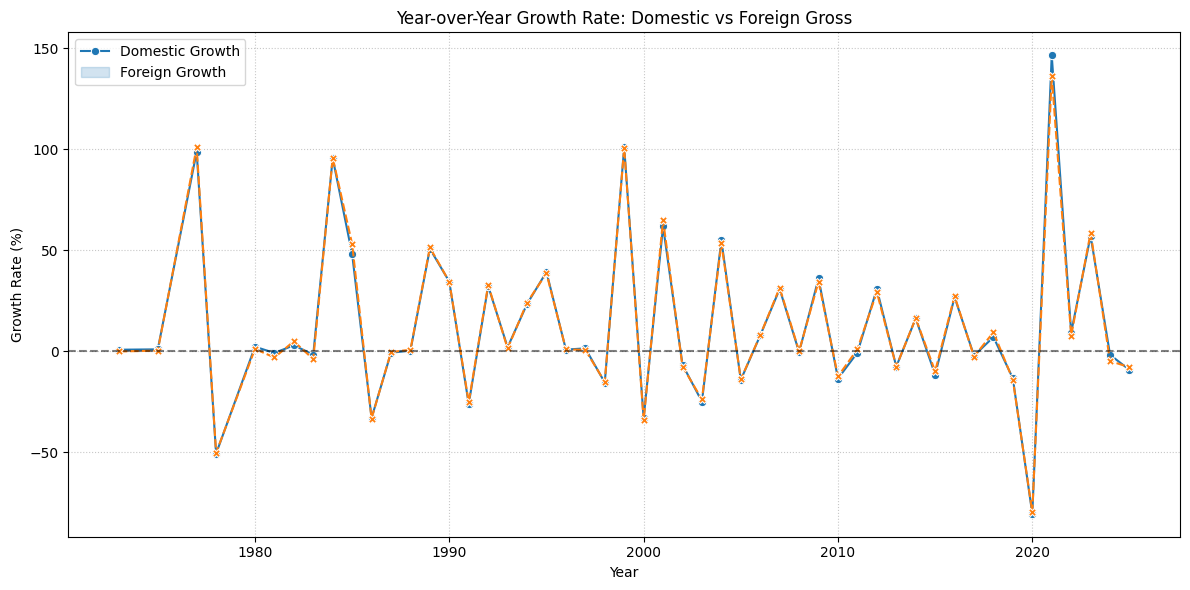


Growth rates and market categories have been calculated and visualized.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by Year and calculate annual sums
annual_gross = df.groupby('Year')[['Domestic Gross', 'Foreign Gross']].sum().sort_index()

# 2. Calculate Year-over-Year growth rates
annual_growth = annual_gross.pct_change() * 100

# 3. Categorize movies based on market dominance
def classify_market(row):
    if row['Foreign %'] > 70:
        return 'International Blockbuster'
    elif row['Domestic %'] > 70:
        return 'Domestic Specialty'
    else:
        return 'Balanced'

df['Market_Category'] = df.apply(classify_market, axis=1)

# 4. Print counts and visualize
category_counts = df['Market_Category'].value_counts()
print("Count of movies in each Market Category:")
print(category_counts)

plt.figure(figsize=(12, 6))
sns.lineplot(data=annual_growth, markers=True)
plt.title('Year-over-Year Growth Rate: Domestic vs Foreign Gross')
plt.ylabel('Growth Rate (%)')
plt.xlabel('Year')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(['Domestic Growth', 'Foreign Growth'])
plt.tight_layout()
plt.show()

print('\nGrowth rates and market categories have been calculated and visualized.')

## Efficiency & Yield Analysis


Evaluataing if a higher reliance on international markets (Foreign %) correlates with higher total revenue efficiency.


**Reasoning**:
In this section, I visualized the relationship between foreign market reliance and worldwide revenue using a regression plot. I then calculated the Pearson correlation and analyzed average revenue by market category to understand the pattern


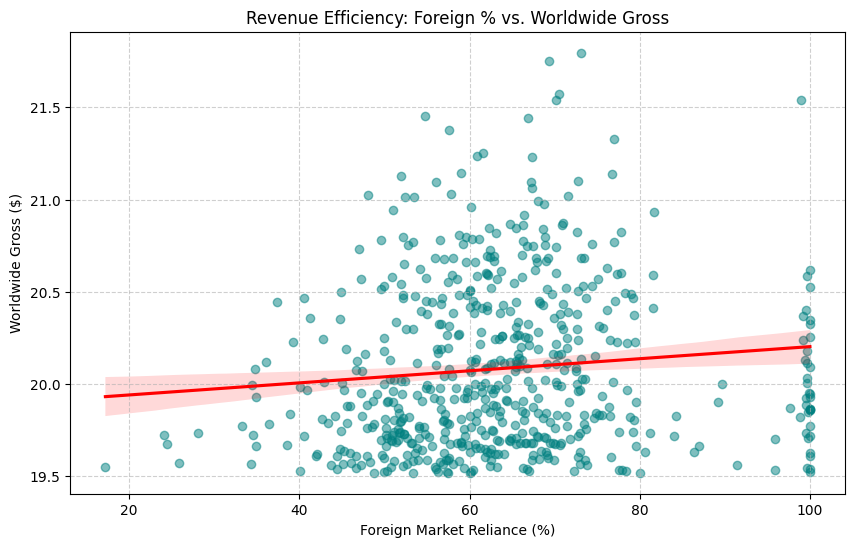

Pearson Correlation (Foreign % vs. Worldwide Gross): 0.1039
P-value: 0.011358465891166476

--- Mean Worldwide Gross by Market Category ---


,mean,median,count
Market_Category,,,
International Blockbuster,20.133828,20.024925,155
Balanced,20.070365,19.954115,433
Domestic Specialty,19.651636,19.674799,5



Insight: The correlation is weak, indicating that total revenue is driven by factors beyond just the domestic/foreign split percentage.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Visualize Relationship: Foreign % vs Worldwide Gross
plt.figure(figsize=(10, 6))
sns.regplot(x='Foreign %', y='Worldwide Gross', data=df,
            scatter_kws={'alpha':0.5, 'color':'teal'},
            line_kws={'color':'red'})

plt.title('Revenue Efficiency: Foreign % vs. Worldwide Gross')
plt.xlabel('Foreign Market Reliance (%)')
plt.ylabel('Worldwide Gross ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Calculate Pearson Correlation
corr_coeff, p_value = pearsonr(df['Foreign %'], df['Worldwide Gross'])
print(f"Pearson Correlation (Foreign % vs. Worldwide Gross): {corr_coeff:.4f}")
print(f"P-value: {p_value}")

# 3. Average Yield by Market Category
yield_analysis = df.groupby('Market_Category')['Worldwide Gross'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)

print('\n--- Mean Worldwide Gross by Market Category ---')
display(yield_analysis)

# 4. Insight
if corr_coeff > 0.3:
    print('\nInsight: There is a notable positive correlation, suggesting that higher reliance on international markets often scales with higher total revenue.')
elif corr_coeff < -0.3:
    print('\nInsight: There is a negative correlation, suggesting that movies with extremely high foreign reliance might actually yield lower total revenue on average.')
else:
    print('\nInsight: The correlation is weak, indicating that total revenue is driven by factors beyond just the domestic/foreign split percentage.')

## Temporal Trends


Examination on how average and median movie grosses have evolved by year and era to identify industry growth patterns.


**Reasoning**:
In this section, I grouped worldwide revenue by year and era and calculated the mean and median values. I then visualized the trends using line and bar charts to study growth patterns..



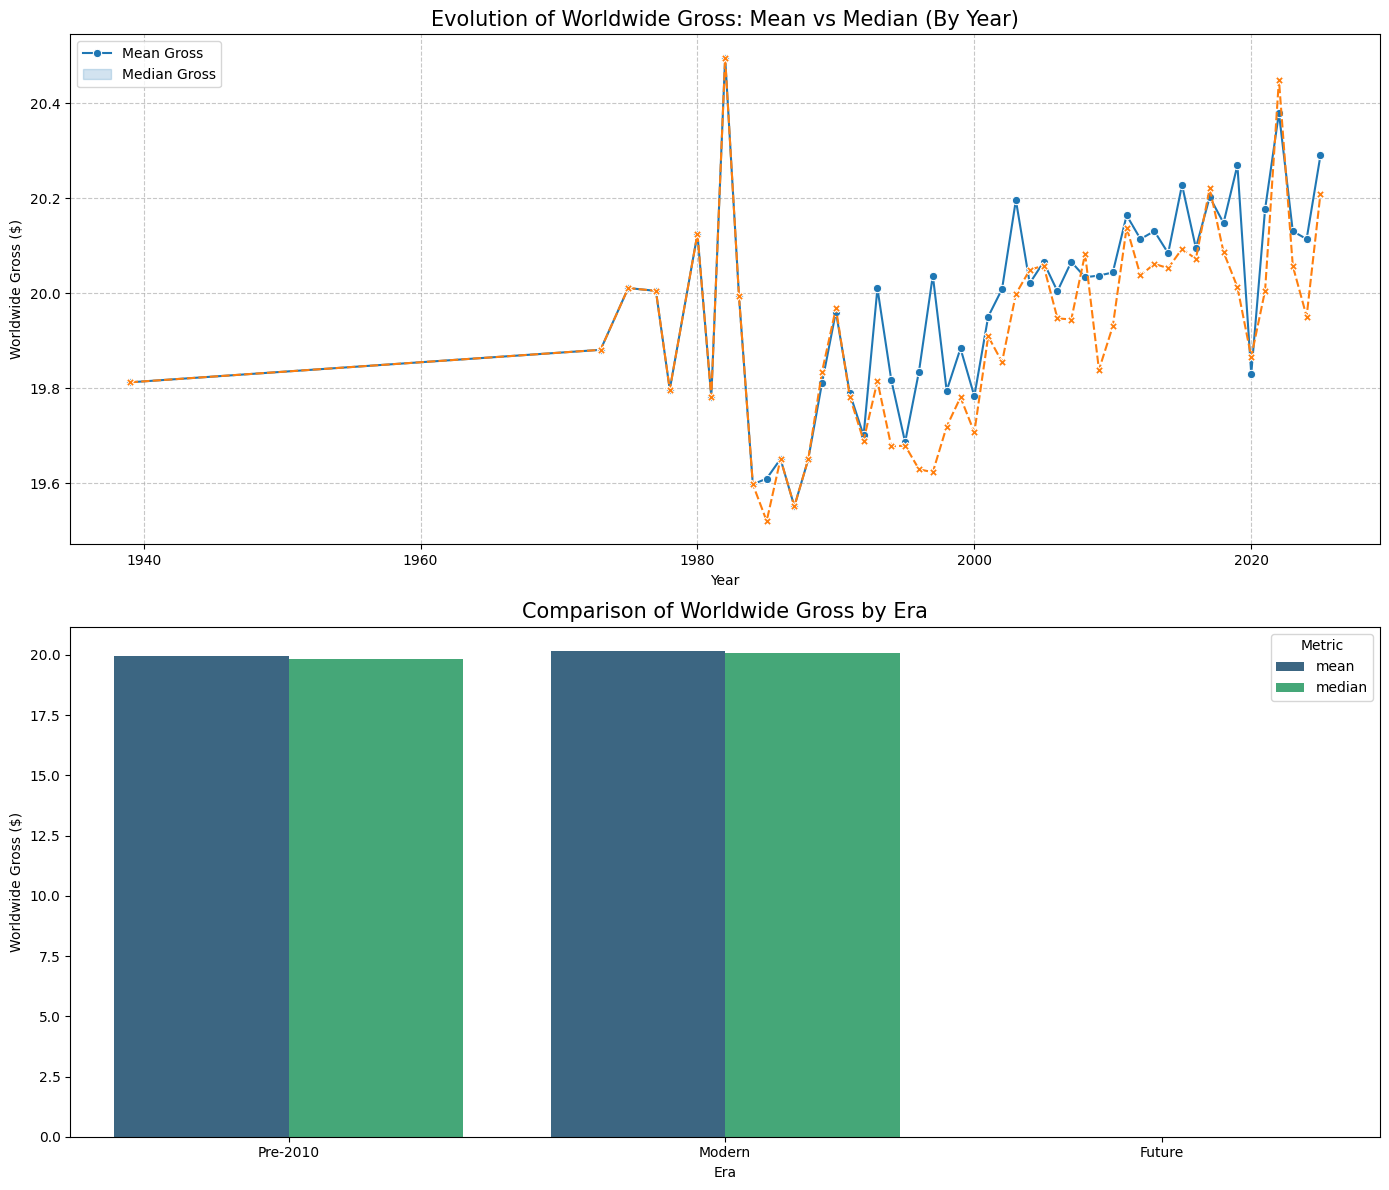

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by Year
yearly_stats = df.groupby('Year')['Worldwide Gross'].agg(['mean', 'median']).sort_index()

# 2. Group by Era
era_stats = df.groupby('Era')['Worldwide Gross'].agg(['mean', 'median']).reindex(['Pre-2010', 'Modern', 'Future'])

# 3. Create Multi-panel Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Yearly Trends (Line Chart)
sns.lineplot(data=yearly_stats, ax=axes[0], markers=True)
axes[0].set_title('Evolution of Worldwide Gross: Mean vs Median (By Year)', fontsize=15)
axes[0].set_ylabel('Worldwide Gross ($)')
axes[0].set_xlabel('Year')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(['Mean Gross', 'Median Gross'])

# Plot 2: Era Comparison (Bar Chart)
era_stats_melted = era_stats.reset_index().melt(id_vars='Era', var_name='Metric', value_name='Gross')
sns.barplot(data=era_stats_melted, x='Era', y='Gross', hue='Metric', ax=axes[1], palette='viridis')
axes[1].set_title('Comparison of Worldwide Gross by Era', fontsize=15)
axes[1].set_ylabel('Worldwide Gross ($)')
axes[1].set_xlabel('Era')

plt.tight_layout()
plt.show()


In [29]:
# 5. Summary of Trends Observations
print('--- Summary of Temporal Trends ---')
print(f"Average Yearly Gross (Max): ${yearly_stats['mean'].max():,.2f} in {yearly_stats['mean'].idxmax()}")
print(f"Median Yearly Gross (Max): ${yearly_stats['median'].max():,.2f} in {yearly_stats['median'].idxmax()}")

print('\nObservations:')
print('1. The Mean is consistently higher than the Median across most years and eras, confirming the influence of high-grossing outliers.')
print('2. There is a noticeable upward trend in gross revenue moving from the Pre-2010 era to the Modern era.')


--- Summary of Temporal Trends ---
Average Yearly Gross (Max): $20.50 in 1982
Median Yearly Gross (Max): $20.50 in 1982

Observations:
1. The Mean is consistently higher than the Median across most years and eras, confirming the influence of high-grossing outliers.
2. There is a noticeable upward trend in gross revenue moving from the Pre-2010 era to the Modern era.




## 📊 Data Analysis Key Findings (What I Found)

* **Market Concentration:**
  The total revenue in the dataset is about **$351.14 billion**. The top-earning movies include **Avatar**, **Avengers: Endgame**, and **Avatar: The Way of Water**. This shows that a few blockbuster movies earn most of the money.

* **Market Segmentation:**
  Most movies fall into the **Balanced** category (433 movies), followed by **International Blockbusters** (155 movies). Very few movies mainly depend on domestic revenue, with only 5 such cases in the dataset.

* **Performance Over Time:**
  The highest average yearly revenue was in **2022**, while the highest median revenue was in **1982**. This shows that recent high averages are often caused by a few very successful movies.

* **Revenue Efficiency:**
  Movies that perform well internationally and those with balanced domestic and foreign revenue usually earn more overall. This shows that international markets are important for high earnings.

---

## 💡 Insights and Next Steps

* **Better Benchmarking:**
  Instead of using the average (Mean), it is better to use the **Median ($471M)** as a realistic target, because the average is influenced by a few extremely successful movies.

* **Separate Market Planning:**
  Since domestic and foreign revenues are weakly related, studios should plan marketing strategies separately for each region instead of relying only on domestic success.







## 🎬 Movie Market Report — Simple Summary

**593 movies analyzed. Here's what the data actually says:**

---

### 💰 Money is Unequal
A small group of blockbuster films earns most of the money. About **65% of movies** drive 80% of total revenue — meaning the movie industry is very much a **"few winners, many losers"** game.

---

### 🌍 Going International Doesn't Guarantee More Money
There's almost **no connection** between how much a film earns internationally and its total worldwide earnings. Domestic and foreign markets behave **independently** — success in one doesn't mean success in the other.

---

### 📈 Industry is Growing — But Not Equally
Movies overall earn more now than before 2010. But that growth is mostly driven by a **handful of mega-blockbusters** (like Avengers, Avatar). The average movie hasn't benefited much.

---

### 🎯 3 Practical Takeaways

| # | Insight | What to do |
|---|---|---|
| 1 | **Average earnings are misleading** | *Use the Median `($471M)` as a realistic target — not the Mean `($592M)` which is inflated by outliers* |
| 2 | **Domestic ≠ International** | *Treat each market as its own separate strategy* |
| 3 | **Don't bet everything on one big film** | *Spread risk across multiple films — the "middle tier" still makes up 85%+ of total volume* |

---

> **Bottom line:** The movie business rewards a few giants heavily, international success is unpredictable, and smart studios plan for the typical film — not the blockbuster exception. 🎬